In [1]:
import sqlite3 
from astropy.table import Table
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import dask.dataframe as dd
roots_tfm = '/home/julien/Documents/Etudes/Astrofisica/Master/TFM/Data'

In [2]:
filepath_match = roots_tfm + '/Swift-UVOT/Match_OM/match_uvot_om'
df = Table.read(filepath_match).to_pandas()
df.head()

,SRCNUM_OM,RA_OM,DEC_OM,POSERR_OM,COUNT_OM,SRCNUM_UVOT,RA_UVOT,DEC_UVOT,POSERR_UVOT,COUNT_UVOT,Separation,angDist
0,5,0.000172,8.371812,0.579813,1,1,0.000160,8.371681,0.273446,1,0.185867,0.475779
1,66,0.004279,8.249917,0.736678,1,10,0.004393,8.250327,0.318405,1,0.484476,1.533487
2,102,0.005933,8.163762,0.709919,1,11,0.005988,8.163922,0.317418,1,0.197048,0.607305
3,182,0.010155,8.307648,0.663965,1,20,0.010337,8.307771,0.316142,1,0.267008,0.785089
4,494,0.026486,8.306166,0.719527,1,64,0.026368,8.306161,0.307228,1,0.136319,0.419898


In [3]:
df.shape[0]

595146

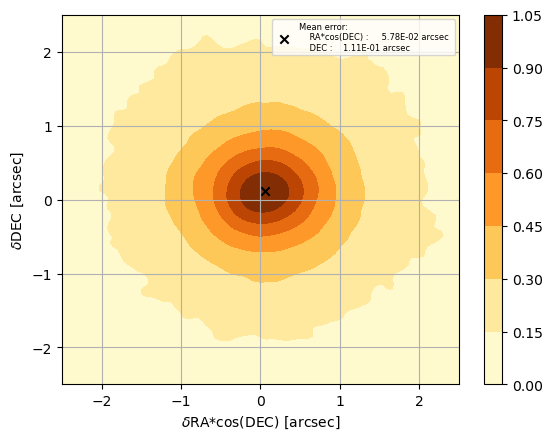

In [4]:
from scipy.stats import gaussian_kde
fig, ax =plt.subplots()
delta_ra_mean = np.mean(3600*(df['RA_OM']-df['RA_UVOT'])*np.cos(np.deg2rad(df['DEC_OM'])))
delta_dec_mean = np.mean(3600*(df['DEC_OM']-df['DEC_UVOT']))
#ax.scatter((df['RA_1']-df['RA_2'])*np.cos(np.deg2rad(df['DEC_1']))*3600,(df['DEC_1']-df['DEC_2'])*3600,color='C0',marker='x')
data = np.vstack([(df['RA_OM']-df['RA_UVOT'])*np.cos(np.deg2rad(df['DEC_OM']))*3600,(df['DEC_OM']-df['DEC_UVOT'])*3600])
kde = gaussian_kde(data)
grid_x, grid_y = np.mgrid[-2.5:2.5:100j, -2.5:2.5:100j]
grid_coords = np.vstack([grid_x.ravel(), grid_y.ravel()])
z = kde(grid_coords).reshape(100, 100)**(1/3)
contour1 = ax.contourf(grid_x, grid_y, z, cmap='YlOrBr')
cbar = plt.colorbar(contour1, ax=ax)
ax.scatter(delta_ra_mean,delta_dec_mean,color='black',marker='x',
           label="Mean error: \n    RA*cos(DEC) :     " +"{:.2E}".format(delta_ra_mean)+ " arcsec \n    DEC :    " + "{:.2E}".format(delta_dec_mean) + " arcsec")
ax.set_xlabel("$\delta$"+"RA*cos(DEC) [arcsec]")
ax.set_ylabel("$\delta$" +"DEC [arcsec]")
plt.legend(loc='upper right',prop={'size': 6})
plt.grid()
fig.savefig(roots_tfm + '/Swift-UVOT/Match_OM/deviation_UVOT_OM.png',dpi=1200) 

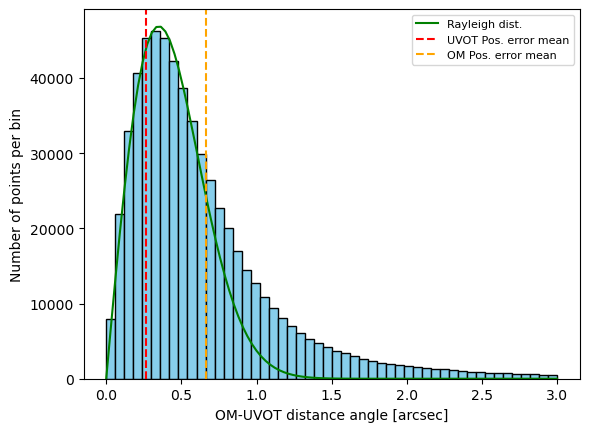

In [5]:
from scipy.stats import rayleigh
# Plot figure
fig, ax =plt.subplots()
(n,bins,patches) = ax.hist(df[df['angDist']<3]['angDist'], bins=50, color='skyblue',edgecolor='black')
x = np.linspace(0,3,100)
ax.plot(x,df.shape[0]*rayleigh.pdf(x,0,0.35)/22,color='green', linestyle='solid',label="Rayleigh dist.")
#ax.hist(df1['Separation'], bins=50, color='skyblue',edgecolor='black')
#ax.hist(df[df['Separation']<1]['Separation'], bins=50, color='magenta',edgecolor='black')
ax.axvline(np.mean(df['POSERR_UVOT']), linestyle='dashed', color='r',label='UVOT Pos. error mean')
ax.axvline(np.mean(df['POSERR_OM']), linestyle='dashed', color='orange',label='OM Pos. error mean')
ax.set_xlabel("OM-UVOT distance angle [arcsec]")
ax.set_ylabel("Number of points per bin")
ax.legend(prop={'size': 8})
fig.savefig(roots_tfm + '/Swift-UVOT/Match_OM/match_UVOT_OM.png',dpi=1200) 

In [6]:
filepath_count = roots_tfm + '/Swift-UVOT/Match_OM/count_random_match.txt'
df_count = pd.read_csv(filepath_count,sep=' ',skiprows=[0],header=None,usecols=[5])
sum = 0
i=0
while sum<(df.shape[0] - df_count[5].mean()):
    sum = sum + n[i]
    i=i+1
print("Sum of cumulated matchs until bin number " + str(i) + " : " + str(sum))
print("Corresponding maximum angle : {:.2E}".format(bins[i]))

Sum of cumulated matchs until bin number 17 : 498643.0
Corresponding maximum angle : 1.02E+00


In [7]:
df_match = df[df['angDist']<1.5]
df_match.shape

(554377, 12)

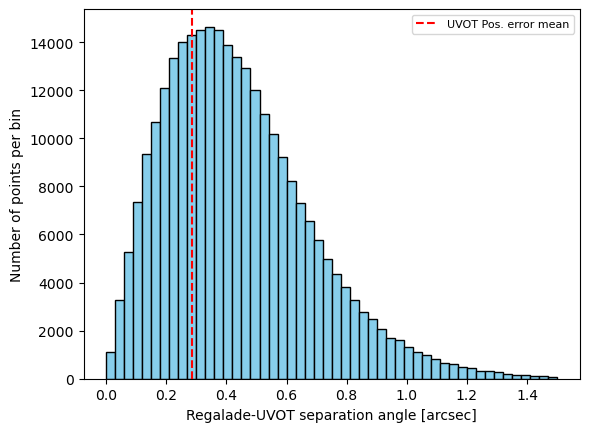

In [8]:
filepath_match = roots_tfm + '/Swift-UVOT/Match_regalade/match_uvot_regalade'
df = Table.read(filepath_match).to_pandas()

# Plot figure
fig, ax =plt.subplots()
(n,bins,patches) = ax.hist(df[df['angDist']<1.5]['angDist'], bins=50, color='skyblue',edgecolor='black')
#ax.hist(df1['Separation'], bins=50, color='skyblue',edgecolor='black')
#ax.hist(df[df['Separation']<1]['Separation'], bins=50, color='magenta',edgecolor='black')
ax.axvline(np.mean(df['POSERR']), linestyle='dashed', color='r',label='UVOT Pos. error mean')
ax.set_xlabel("Regalade-UVOT separation angle [arcsec]")
ax.set_ylabel("Number of points per bin")
ax.legend(prop={'size': 8})
fig.savefig(roots_tfm + '/Swift-UVOT/Match_regalade/match_uvot_regalade.png',dpi=1200) 

In [9]:
df_uvot = df[df['angDist']<1.5]
df_uvot.shape

(280270, 9)

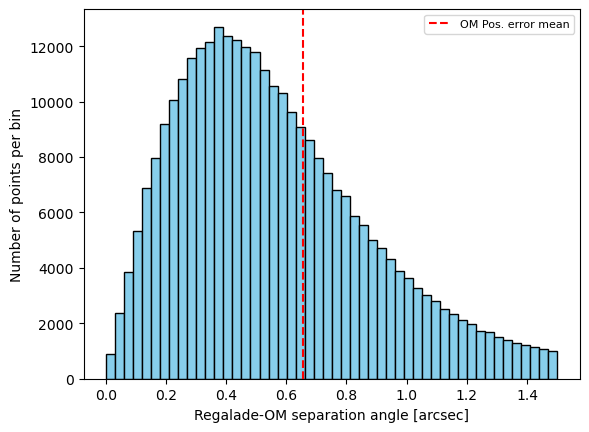

In [10]:
filepath_match = roots_tfm + '/XMM-Newton/Match_regalade/match_om_regalade'
df = Table.read(filepath_match).to_pandas()

# Plot figure
fig, ax =plt.subplots()
(n,bins,patches) = ax.hist(df[df['angDist']<1.5]['angDist'], bins=50, color='skyblue',edgecolor='black')
#ax.hist(df1['Separation'], bins=50, color='skyblue',edgecolor='black')
#ax.hist(df[df['Separation']<1]['Separation'], bins=50, color='magenta',edgecolor='black')
ax.axvline(np.mean(df['POSERR']), linestyle='dashed', color='r',label='OM Pos. error mean')
ax.set_xlabel("Regalade-OM separation angle [arcsec]")
ax.set_ylabel("Number of points per bin")
ax.legend(prop={'size': 8})
fig.savefig(roots_tfm + '/XMM-Newton/Match_regalade/match_om_regalade.png',dpi=1200)

In [11]:
df_om = df[df['angDist']<1.5]
df_om.shape

(305209, 9)

In [12]:
# Select only the galaxies source
df = df_match[df_match['SRCNUM_UVOT'].isin(df_uvot['SRCNUM']) & df_match['SRCNUM_OM'].isin(df_om['SRCNUM'])]
df.shape

(21138, 12)

In [13]:
# Get problematic right ascension edge points
ind = abs(df['RA_OM']-df['RA_UVOT'])>10
if len(df[ind].index)>0:
    df_extract = pd.DataFrame(df, columns=['RA_OM','RA_UVOT'])
    ind_max = df_extract.loc[ind,:].idxmax(axis=1)
    df.iloc[ind,ind_max]  = df.iloc[ind,ind_max] - 360

# Perform the weighted mean
df.loc[:,'RA'] = (df['RA_OM']/df['POSERR_OM']+df['RA_UVOT']/df['POSERR_UVOT'])/(1/df['POSERR_OM']+1/df['POSERR_UVOT'])
df.loc[:,'DEC'] = (df['DEC_OM']/df['POSERR_OM']+df['DEC_UVOT']/df['POSERR_UVOT'])/(1/df['POSERR_OM']+1/df['POSERR_UVOT'])

# Correct negative point on the edge
df.loc[df.loc[:, 'RA']<0, 'RA'] = df.loc[df.loc[:, 'RA']<0, 'RA'] + 360

# Perform the mean of the position error
df.loc[:,'POSERR'] = (df['POSERR_OM']+df['POSERR_UVOT']) / 2

/tmp/ipykernel_91635/1806534486.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:,'RA'] = (df['RA_OM']/df['POSERR_OM']+df['RA_UVOT']/df['POSERR_UVOT'])/(1/df['POSERR_OM']+1/df['POSERR_UVOT'])
/tmp/ipykernel_91635/1806534486.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[:,'DEC'] = (df['DEC_OM']/df['POSERR_OM']+df['DEC_UVOT']/df['POSERR_UVOT'])/(1/df['POSERR_OM']+1/df['POSERR_UVOT'])
/tmp/ipykernel_91635/1806534486.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy 

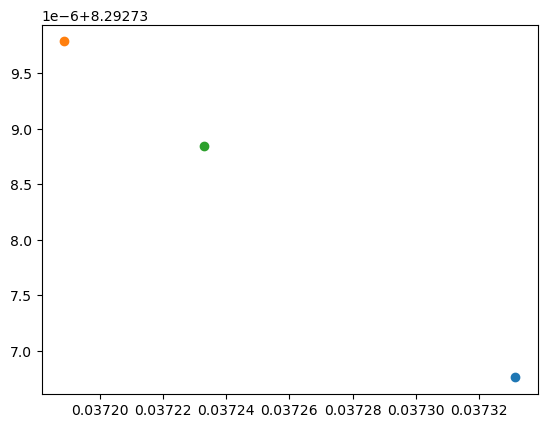

In [14]:
# Print some points to verify it works
plt.scatter(df.loc[df.index[1],'RA_OM'],df.loc[df.index[1],'DEC_OM'],color='C0',label='OM')
plt.scatter(df.loc[df.index[1],'RA_UVOT'],df.loc[df.index[1],'DEC_UVOT'],color='C1',label='UVOT')
plt.scatter(df.loc[df.index[1],'RA'],df.loc[df.index[1],'DEC'],color='C2',label='Tot')

In [15]:
# Clean unecessary columns
df = df.drop({'RA_OM','POSERR_OM','RA_UVOT','POSERR_UVOT','DEC_OM','DEC_UVOT','Separation', 'angDist'},axis=1)

# Create the total count column and remove the individual one
df['COUNT'] = df['COUNT_OM'] + df['COUNT_UVOT']
df = df.drop({'COUNT_OM','COUNT_UVOT'},axis=1)
df.head()

,SRCNUM_OM,SRCNUM_UVOT,RA,DEC,POSERR,COUNT
4,494,64,0.026404,8.306162,0.513378,2
6,707,106,0.037233,8.292739,0.462647,2
12,1240,202,0.065896,8.257068,0.823770,2
21,2434,385,0.128606,8.379366,0.465628,2
369,11932,10864,1.436870,20.170847,0.496872,17


In [16]:
# Load UVOT data per source
#filepath_uvot = roots_tfm + '/Swift-UVOT/uvot_ra_dec_per_src.fits'
#dat = Table.read(filepath_uvot)
#df_uvot = dat.to_pandas()
df_uvot.head()

,SRCNUM,RA_1,DEC_1,POSERR,COUNT,ra_2,dec_2,Separation,angDist
0,5,0.001106,-40.113253,0.477914,1,0.001356,-40.113201,0.496769,0.712239
1,10,0.004393,8.250327,0.318405,1,0.004506,8.250304,0.429508,0.410272
2,17,0.008504,8.360581,0.332229,1,0.008604,8.360579,0.356585,0.355404
3,22,0.010610,8.298201,0.340089,1,0.010690,8.298277,0.384756,0.392554
4,30,0.013978,8.190792,0.349532,1,0.013959,8.190620,0.591361,0.620098


In [17]:
# Adapt the column format to the match table for the concatenation
df_uvot['SRCNUM_OM'] = 0
df_uvot = df_uvot.rename(columns={'SRCNUM':'SRCNUM_UVOT','RA_1': 'RA', 'DEC_1' : 'DEC'})
df_uvot=df_uvot[list(df.columns.values)]

In [18]:
# Concatenate the match table with UVOT and remove duplicated raw
df_uvot = pd.concat([df, df_uvot], ignore_index = True).drop_duplicates(subset=['SRCNUM_UVOT'])
df_uvot.shape

(280270, 6)

In [19]:
df_uvot.dtypes

SRCNUM_OM        int64
SRCNUM_UVOT      int32
RA             float64
DEC            float64
POSERR         float64
COUNT            int64
dtype: object

In [20]:
df_uvot = df_uvot.astype({'COUNT': np.uint16, 'SRCNUM_OM': np.int32, 'POSERR': np.float32})
df_uvot = df_uvot.sort_values('SRCNUM_UVOT')
#t1 = Table.from_pandas(df_uvot,index=False)
#t1.write(roots_tfm + '/Swift-UVOT/SOURCE_UVOT.fits',overwrite='True')

In [21]:
# Load OM data per source and prepare the column format to the concatenation
#filepath_om = roots_tfm + '/XMM-Newton/SUSS6_ra_dec_per_src.fits'
#dat = Table.read(filepath_om)
#df_om = dat.to_pandas()
df_om['SRCNUM_UVOT'] = 0
df_om = df_om.rename(columns={'SRCNUM':'SRCNUM_OM','RA_1': 'RA', 'DEC_1' : 'DEC'})
df_om=df_om[list(df.columns.values)]

In [22]:
# Concatenate OM data with match table and remove the duplicated raw
#df_om = pd.concat([df, df_om], ignore_index = True).drop_duplicates(subset=['SRCNUM_2'])
#df_om.shape

In [23]:
df_om.dtypes

SRCNUM_OM        int32
SRCNUM_UVOT      int64
RA             float64
DEC            float64
POSERR         float64
COUNT            int64
dtype: object

In [24]:
df_om = df_om.astype({'SRCNUM_OM': np.int32, 'COUNT': np.uint16, 'SRCNUM_UVOT': np.int32, 'POSERR': np.float32})
df_om = df_om.sort_values('SRCNUM_OM')
#t1 = Table.from_pandas(df_om,index=False)
#t1.write(roots_tfm + '/XMM-Newton/SOURCE_OM.fits',overwrite='True')

In [25]:
# Concatenate the tables of both catalogue droping match duplicated
#df_tot = dd.concat([dd.from_pandas(df_uvot,npartitions=2), dd.from_pandas(df_om,npartitions=2)]).drop_duplicates()
df_tot = pd.concat([df_uvot, df_om], ignore_index = True).drop_duplicates()
#df_tot.shape

In [26]:
df_tot.to_csv(roots_tfm + '/SOURCE_complete_galaxies.csv',index=True)

In [27]:
#df_tot.loc[df_tot.loc[:,'COUNT']>2,'COUNT'].shape

In [28]:
#df_tot.head()

In [29]:
#df_tot.dtypes

In [30]:
#t1 = Table.from_pandas(df_tot,index=True)
#t1.write(roots_tfm + '/SOURCE_complete.fits',overwrite='True')

In [31]:
#t1 = Table.from_pandas(df_tot.loc[df_tot.loc[:,'COUNT']>2,:],index=True)
#t1.write(roots_tfm + '/SOURCE_selection_count_sup_2.fits',overwrite='True')

In [ ]:
db_path ='sqlite:///'+ roots_tfm + '/UVCatalogue.db'
df_tot.to_sql("SOURCES", db_path, if_exists='replace', index=True, chunksize=1000, method="multi")

In [ ]:
df_tot.head()